# EXECUCAO COMPLETA - TODOS OS MODELOS COMPARATIVOS

Este notebook executa todos os modelos comparativos (GBML, ROSE, HAT, ARF, SRP, ACDWM, ERulesD2S) em todos os 52 datasets dos 7 batches.

**Modelos:**
- GBML (resultados ja existentes)
- ROSE (novo - Robust Online Self-Adjusting Ensemble)
- HAT (Hoeffding Adaptive Tree)
- ARF (Adaptive Random Forest)
- SRP (Streaming Random Patches)
- ACDWM (Adaptive Chunk-based DWM)
- ERulesD2S (Evolutionary Rules for Data Streams)

**Tratamento de Erros:**
- Se um modelo falha em um dataset (ex: ACDWM em multiclasse), assume G-mean = 0

**Analise Estatistica:**
- Friedman Test
- Nemenyi Post-hoc com correcao de Bonferroni
- Critical Difference Diagram
- Wilcoxon Signed-Rank Tests

**Tempo Estimado:** 8-12 horas (todos os modelos em todos os datasets)

---
## PARTE 1: SETUP DO AMBIENTE
---

In [ ]:
# CELULA 1.1: Montar Google Drive
from google.colab import drive
import os
import sys
from pathlib import Path

drive.mount('/content/drive')

# CONFIGURAR PATH DO PROJETO NO DRIVE
# Ajuste conforme sua estrutura
DRIVE_BASE = "/content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid"

# Verificar se existe
if not os.path.exists(DRIVE_BASE):
    # Tentar path alternativo
    DRIVE_BASE = "/content/drive/MyDrive/DSL-AG-hybrid"
    if not os.path.exists(DRIVE_BASE):
        print("ERRO: Diretorio nao encontrado!")
        print("Por favor, ajuste DRIVE_BASE para o caminho correto do projeto.")
        raise FileNotFoundError("Diretorio do projeto nao encontrado")

WORK_DIR = "/content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid"

print(f"Drive montado com sucesso!")
print(f"Diretorio base: {DRIVE_BASE}")

Mounted at /content/drive
Drive montado com sucesso!
Diretorio base: /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid


In [ ]:
# # CELULA 1.2: Copiar Repositorio para /content
# if os.path.exists(WORK_DIR):
#     print("Removendo diretorio antigo...")
#     !rm -rf {WORK_DIR}

# print(f"Copiando repositorio...")
# !cp -r "{DRIVE_BASE}" {WORK_DIR}

os.chdir(WORK_DIR)
print(f"Diretorio de trabalho: {os.getcwd()}")

# Verificar estrutura
print("\nPastas de experimentos:")
!ls -d experiments_*/

Diretorio de trabalho: /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid

Pastas de experimentos:
experiments_6chunks_phase1_gbml/  experiments_6chunks_phase3_real/
experiments_6chunks_phase2_gbml/  experiments_test/


In [ ]:
# CELULA 1.3: Instalar Java 11 e Maven (necessario para ROSE e ERulesD2S)
#
# Java 11 e requerido pelo ERulesD2S (JCLEC4)
# Maven e necessario para compilar dependencias Java

print("Instalando Java 11 e Maven...")

!apt-get update -qq
!apt-get install -y -qq openjdk-11-jdk maven > /dev/null 2>&1

# Configurar JAVA_HOME (importante para ERulesD2S)
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PATH'] = os.environ['JAVA_HOME'] + '/bin:' + os.environ['PATH']

# Verificar instalacoes
print("\n--- Java ---")
!java -version

print("\n--- Maven ---")
!mvn -version 2>/dev/null | head -3

print("\nJava 11 e Maven instalados com sucesso!")
print(f"JAVA_HOME: {os.environ.get('JAVA_HOME', 'NAO DEFINIDO')}")

Instalando Java 11 e Maven...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

--- Java ---
openjdk version "11.0.29" 2025-10-21
OpenJDK Runtime Environment (build 11.0.29+7-post-Ubuntu-1ubuntu122.04)
OpenJDK 64-Bit Server VM (build 11.0.29+7-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)

--- Maven ---
Apache Maven 3.6.3
Maven home: /usr/share/maven
Java version: 11.0.29, vendor: Ubuntu, runtime: /usr/lib/jvm/java-11-openjdk-amd64

Java 11 e Maven instalados com sucesso!
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64


In [ ]:
# CELULA 1.4: Instalar Dependencias Python
print("Instalando dependencias Python...")
!pip install -q river scikit-learn scipy pyyaml matplotlib seaborn pandas numpy
!pip install -q scikit-posthocs  # Para testes post-hoc

import river
print(f"River version: {river.__version__}")
print("Dependencias instaladas com sucesso!")

Instalando dependencias Python...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
River version: 0.23.0
Dependencias instaladas com sucesso!


In [ ]:
# CELULA 1.5: Baixar JARs do ROSE
import urllib.request
from pathlib import Path

rose_dir = Path('rose_jars')
rose_dir.mkdir(exist_ok=True)

base_url = "https://github.com/canoalberto/ROSE/raw/master"
jars = [
    "ROSE-1.0.jar",
    "MOA-dependencies.jar",
    "sizeofag-1.0.4.jar"
]

for jar in jars:
    jar_path = rose_dir / jar
    if not jar_path.exists():
        url = f"{base_url}/{jar}"
        print(f"Baixando {jar}...")
        urllib.request.urlretrieve(url, jar_path)
        size_mb = jar_path.stat().st_size / (1024 * 1024)
        print(f"  Concluido: {size_mb:.2f} MB")
    else:
        print(f"JAR ja existe: {jar}")

print("\nJARs ROSE disponiveis!")

JAR ja existe: ROSE-1.0.jar
JAR ja existe: MOA-dependencies.jar
JAR ja existe: sizeofag-1.0.4.jar

JARs ROSE disponiveis!


In [ ]:
# CELULA 1.6: Clonar ACDWM Repository
ACDWM_DIR = "/content/ACDWM"

if not os.path.exists(ACDWM_DIR):
    print("Clonando repositorio ACDWM...")
    !git clone https://github.com/jasonyanglu/ACDWM.git {ACDWM_DIR}
    print(f"ACDWM clonado em: {ACDWM_DIR}")
else:
    print(f"ACDWM ja existe em: {ACDWM_DIR}")

Clonando repositorio ACDWM...
Cloning into '/content/ACDWM'...
remote: Enumerating objects: 117, done.
remote: Total 117 (delta 0), reused 0 (delta 0), pack-reused 117 (from 1)
Receiving objects: 100% (117/117), 14.80 MiB | 16.22 MiB/s, done.
Resolving deltas: 100% (26/26), done.
ACDWM clonado em: /content/ACDWM


In [ ]:
# CELULA 1.7: Setup ERulesD2S
#
# ERulesD2S requer:
# - Java 11 (instalado na celula anterior)
# - erulesd2s.jar
# - JCLEC4-base-1.0-jar-with-dependencies.jar (na pasta lib/)

from pathlib import Path
import os

print("="*60)
print("CONFIGURANDO ERulesD2S")
print("="*60)

# Verificar JAVA_HOME
java_home = os.environ.get('JAVA_HOME', '')
if java_home:
    print(f"JAVA_HOME: {java_home}")
else:
    print("AVISO: JAVA_HOME nao definido - definindo agora...")
    os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
    print(f"JAVA_HOME: {os.environ['JAVA_HOME']}")

# Verificar se JAR existe
erulesd2s_jar = Path(WORK_DIR) / "erulesd2s.jar"
jclec_jar = Path(WORK_DIR) / "lib" / "JCLEC4-base-1.0-jar-with-dependencies.jar"

print(f"\nVerificando JARs...")
print(f"  erulesd2s.jar: {'ENCONTRADO' if erulesd2s_jar.exists() else 'NAO ENCONTRADO'}")
print(f"  JCLEC4 JAR: {'ENCONTRADO' if jclec_jar.exists() else 'NAO ENCONTRADO'}")

# Se JAR nao existe, executar setup
if not erulesd2s_jar.exists():
    print("\nExecutando setup_erulesd2s.py...")
    setup_script = Path(WORK_DIR) / "setup_erulesd2s.py"

    if setup_script.exists():
        !cd {WORK_DIR} && python setup_erulesd2s.py

        # Verificar novamente
        if erulesd2s_jar.exists():
            print("\nERulesD2S configurado com sucesso!")
            print(f"  JAR: {erulesd2s_jar}")

            # Verificar JCLEC4
            if jclec_jar.exists():
                print(f"  JCLEC4: {jclec_jar}")
            else:
                print("  AVISO: JCLEC4 JAR nao encontrado - ERulesD2S pode falhar!")
        else:
            print("\nERRO: erulesd2s.jar nao foi criado!")
            print("ERulesD2S sera ignorado nos experimentos.")
    else:
        print(f"\nERRO: {setup_script} nao encontrado!")
        print("ERulesD2S sera ignorado nos experimentos.")
else:
    print("\nERulesD2S ja esta configurado!")

    # Verificar JCLEC4 mesmo assim
    if not jclec_jar.exists():
        print("AVISO: JCLEC4 JAR nao encontrado - ERulesD2S pode falhar!")

# Listar pasta lib se existir
lib_dir = Path(WORK_DIR) / "lib"
if lib_dir.exists():
    print(f"\nConteudo da pasta lib/:")
    !ls -lh {lib_dir}/*.jar 2>/dev/null | head -5

print("\n" + "="*60)

CONFIGURANDO ERulesD2S
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64

Verificando JARs...
  erulesd2s.jar: ENCONTRADO
  JCLEC4 JAR: ENCONTRADO

ERulesD2S ja esta configurado!

Conteudo da pasta lib/:
-rw------- 1 root root 30M Nov 14 00:55 /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/lib/JCLEC4-base-1.0-jar-with-dependencies.jar



## CELULA 1.8: Verificacao do Ambiente (Opcional)

Execute a proxima celula para verificar se todos os componentes estao instalados corretamente.

---
## PARTE 2: CONFIGURACAO DOS EXPERIMENTOS
---

In [ ]:
# CELULA 1.8: Verificar Ambiente (Diagnostico)
#
# Esta celula verifica se todos os componentes basicos estao prontos

from pathlib import Path

print("="*80)
print("VERIFICACAO DO AMBIENTE")
print("="*80)

# 1. Verificar Java
print("\n1. JAVA")
!java -version 2>&1 | head -1

# 2. Verificar Maven
print("\n2. MAVEN")
!mvn -version 2>/dev/null | head -1

# 3. Verificar JARs ROSE
print("\n3. JARs ROSE")
rose_dir = Path(WORK_DIR) / 'rose_jars'
for jar in ['ROSE-1.0.jar', 'MOA-dependencies.jar', 'sizeofag-1.0.4.jar']:
    jar_path = rose_dir / jar
    status = 'OK' if jar_path.exists() else 'FALTANDO'
    size = f"({jar_path.stat().st_size / 1024 / 1024:.1f} MB)" if jar_path.exists() else ""
    print(f"   {jar}: {status} {size}")

# 4. Verificar ACDWM (usa dwmil.py, NAO ACDWM.py)
print("\n4. ACDWM")
dwmil_file = Path(ACDWM_DIR) / "dwmil.py"
chunk_methods_file = Path(ACDWM_DIR) / "chunk_based_methods.py"
underbagging_file = Path(ACDWM_DIR) / "underbagging.py"
print(f"   dwmil.py: {'OK' if dwmil_file.exists() else 'FALTANDO'}")
print(f"   chunk_based_methods.py: {'OK' if chunk_methods_file.exists() else 'FALTANDO'}")
print(f"   underbagging.py: {'OK' if underbagging_file.exists() else 'FALTANDO'}")

# 5. Verificar ERulesD2S
print("\n5. ERulesD2S")
erulesd2s_jar = Path(WORK_DIR) / "erulesd2s.jar"
jclec_jar = Path(WORK_DIR) / "lib" / "JCLEC4-base-1.0-jar-with-dependencies.jar"
print(f"   erulesd2s.jar: {'OK' if erulesd2s_jar.exists() else 'FALTANDO (sera ignorado)'}")
print(f"   JCLEC4 JAR: {'OK' if jclec_jar.exists() else 'FALTANDO'}")

# 6. Verificar pastas de experimentos
print("\n6. PASTAS DE EXPERIMENTOS")
exp_dirs = [
    'experiments_6chunks_phase2_gbml',
    'experiments_6chunks_phase3_real'
]
for exp_dir in exp_dirs:
    exp_path = Path(WORK_DIR) / exp_dir
    if exp_path.exists():
        batches = [d.name for d in exp_path.iterdir() if d.is_dir() and d.name.startswith('batch')]
        print(f"   {exp_dir}: {len(batches)} batches")
    else:
        print(f"   {exp_dir}: NAO ENCONTRADO")

print("\n" + "="*80)
print("VERIFICACAO CONCLUIDA")
print("="*80)
print("\nSe todos os componentes estao OK, prossiga para PARTE 2.")

VERIFICACAO DO AMBIENTE

1. JAVA
openjdk version "11.0.29" 2025-10-21

2. MAVEN
Apache Maven 3.6.3

3. JARs ROSE
   ROSE-1.0.jar: OK (0.1 MB)
   MOA-dependencies.jar: OK (61.6 MB)
   sizeofag-1.0.4.jar: OK (0.0 MB)

4. ACDWM
   dwmil.py: OK
   chunk_based_methods.py: OK
   underbagging.py: OK

5. ERulesD2S
   erulesd2s.jar: OK
   JCLEC4 JAR: OK

6. PASTAS DE EXPERIMENTOS
   experiments_6chunks_phase2_gbml: 4 batches
   experiments_6chunks_phase3_real: 3 batches

VERIFICACAO CONCLUIDA

Se todos os componentes estao OK, prossiga para PARTE 2.


In [ ]:
# CELULA 2.1: Definir Configuracoes
import numpy as np
import pandas as pd
import json
import subprocess
import time
from datetime import datetime
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuracao dos Batches
BATCH_CONFIG = {
    'batch_1': {
        'phase': 'phase2',
        'base_dir': 'experiments_6chunks_phase2_gbml/batch_1',
        'datasets': [
            'SEA_Abrupt_Simple', 'SEA_Abrupt_Chain', 'SEA_Abrupt_Recurring',
            'AGRAWAL_Abrupt_Simple_Mild', 'AGRAWAL_Abrupt_Simple_Severe', 'AGRAWAL_Abrupt_Chain_Long',
            'RBF_Abrupt_Severe', 'RBF_Abrupt_Blip',
            'STAGGER_Abrupt_Chain', 'STAGGER_Abrupt_Recurring',
            'HYPERPLANE_Abrupt_Simple', 'RANDOMTREE_Abrupt_Simple'
        ]
    },
    'batch_2': {
        'phase': 'phase2',
        'base_dir': 'experiments_6chunks_phase2_gbml/batch_2',
        'datasets': [
            'SEA_Gradual_Simple_Fast', 'SEA_Gradual_Simple_Slow', 'SEA_Gradual_Recurring',
            'STAGGER_Gradual_Chain',
            'RBF_Gradual_Moderate', 'RBF_Gradual_Severe',
            'HYPERPLANE_Gradual_Simple', 'RANDOMTREE_Gradual_Simple', 'LED_Gradual_Simple'
        ]
    },
    'batch_3': {
        'phase': 'phase2',
        'base_dir': 'experiments_6chunks_phase2_gbml/batch_3',
        'datasets': [
            'SEA_Abrupt_Chain_Noise', 'STAGGER_Abrupt_Chain_Noise',
            'AGRAWAL_Abrupt_Simple_Severe_Noise', 'SINE_Abrupt_Recurring_Noise',
            'RBF_Abrupt_Blip_Noise', 'RBF_Gradual_Severe_Noise',
            'HYPERPLANE_Gradual_Noise', 'RANDOMTREE_Gradual_Noise'
        ]
    },
    'batch_4': {
        'phase': 'phase2',
        'base_dir': 'experiments_6chunks_phase2_gbml/batch_4',
        'datasets': [
            'SINE_Abrupt_Simple', 'SINE_Gradual_Recurring',
            'LED_Abrupt_Simple',
            'WAVEFORM_Abrupt_Simple', 'WAVEFORM_Gradual_Simple',
            'RANDOMTREE_Abrupt_Recurring'
        ]
    },
    'batch_5': {
        'phase': 'phase3',
        'base_dir': 'experiments_6chunks_phase3_real/batch_5',
        'datasets': [
            'Electricity', 'Shuttle', 'CovType', 'PokerHand', 'IntelLabSensors'
        ]
    },
    'batch_6': {
        'phase': 'phase3',
        'base_dir': 'experiments_6chunks_phase3_real/batch_6',
        'datasets': [
            'SEA_Stationary', 'AGRAWAL_Stationary', 'RBF_Stationary',
            'LED_Stationary', 'HYPERPLANE_Stationary', 'RANDOMTREE_Stationary'
        ]
    },
    'batch_7': {
        'phase': 'phase3',
        'base_dir': 'experiments_6chunks_phase3_real/batch_7',
        'datasets': [
            'STAGGER_Stationary', 'WAVEFORM_Stationary', 'SINE_Stationary',
            'AssetNegotiation_F2', 'AssetNegotiation_F3', 'AssetNegotiation_F4'
        ]
    }
}

# ============================================================
# MODELOS A EXECUTAR
# ============================================================
# DUAS VERSOES DO ROSE:
#   - ROSE_Original: Como no paper (prequential, metrica global)
#   - ROSE_ChunkEval: Avaliacao por chunk (comparavel com GBML)
#
# Outros modelos: HAT, ARF, SRP, ACDWM, ERulesD2S
# ============================================================

MODELS_TO_RUN = [
    'ROSE_Original',   # ROSE como no paper (metrica global)
    'ROSE_ChunkEval',  # ROSE com avaliacao por chunk (comparavel GBML)
    'HAT',             # Hoeffding Adaptive Tree
    'ARF',             # Adaptive Random Forest
    'SRP',             # Streaming Random Patches
    'ACDWM',           # Adaptive Chunk-based DWM (so binario!)
    'ERulesD2S'        # Evolutionary Rules (usa cache)
]

# Batches a processar (ajuste conforme necessario)
BATCHES_TO_RUN = ['batch_1', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7']

# Timeout por modelo (segundos)
MODEL_TIMEOUT = {
    'ROSE_Original': 600,
    'ROSE_ChunkEval': 600,
    'HAT': 300,
    'ARF': 600,
    'SRP': 600,
    'ACDWM': 600,
    'ERulesD2S': 1800
}

# Tamanho do chunk para avaliacao (usado por ROSE_ChunkEval e outros)
CHUNK_SIZE = 1000  # Mesmo tamanho usado pelo GBML

print("Configuracao carregada!")
print(f"Batches a processar: {BATCHES_TO_RUN}")
print(f"Modelos a executar: {MODELS_TO_RUN}")
print()
print("DUAS VERSOES DO ROSE:")
print("  - ROSE_Original: Prequential (como no paper)")
print("  - ROSE_ChunkEval: Avaliacao por chunk (comparavel GBML)")

# Contar total de datasets
total_datasets = sum(len(BATCH_CONFIG[b]['datasets']) for b in BATCHES_TO_RUN)
print(f"\nTotal de datasets: {total_datasets}")

Configuracao carregada!
Batches a processar: ['batch_1', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7']
Modelos a executar: ['ROSE_Original', 'ROSE_ChunkEval', 'HAT', 'ARF', 'SRP', 'ACDWM', 'ERulesD2S']

DUAS VERSOES DO ROSE:
  - ROSE_Original: Prequential (como no paper)
  - ROSE_ChunkEval: Avaliacao por chunk (comparavel GBML)

Total de datasets: 52


---
## PARTE 3: FUNCOES AUXILIARES
---

In [ ]:
# CELULA 3.1: Funcoes para ARFF e ROSE
#
# DUAS VERSOES DO ROSE:
#
# 1. ROSE_Original: Prequential instance-by-instance (como no paper)
#    - Avalia a cada 500 instancias (padrao MOA)
#    - Retorna metrica GLOBAL do stream completo
#    - Vantagem: Adapta rapidamente a cada instancia
#
# 2. ROSE_ChunkEval: Com avaliacao por chunk (comparacao justa com GBML)
#    - Avalia a cada chunk (ex: 1000 instancias)
#    - Retorna MEDIA das metricas por chunk
#    - Comparavel com GBML que avalia chunk-by-chunk
#
# EVALUATORS:
#   - WindowAUCImbalancedPerformanceEvaluator: para BINARIO (2 classes)
#   - WindowAUCMultiClassImbalancedPerformanceEvaluator: para MULTICLASSE (3+ classes)

def get_rose_evaluator(n_classes):
    """
    Retorna o evaluator correto baseado no numero de classes.
    """
    if n_classes <= 2:
        return "WindowAUCImbalancedPerformanceEvaluator"
    else:
        return "WindowAUCMultiClassImbalancedPerformanceEvaluator"


def create_arff_file(X, y, output_path, relation_name="stream"):
    """Cria arquivo ARFF a partir de dados numpy."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    n_samples, n_features = X.shape
    classes = sorted(np.unique(y))

    with open(output_path, 'w') as f:
        f.write(f"@relation {relation_name}\n\n")
        for i in range(n_features):
            f.write(f"@attribute attr{i} numeric\n")
        class_str = ",".join([str(c) for c in classes])
        f.write(f"@attribute class {{{class_str}}}\n\n")
        f.write("@data\n")
        for i in range(n_samples):
            row = ",".join([str(x) for x in X[i]]) + f",{y[i]}\n"
            f.write(row)

    return output_path


def run_rose_original(arff_file, output_dir, n_classes=2, max_instances=None, timeout=600):
    """
    ROSE_Original: Executa ROSE como no paper original.

    - Prequential instance-by-instance
    - Avaliacao a cada 500 instancias (padrao MOA)
    - Retorna metrica GLOBAL do stream completo (ultima linha do CSV)

    Args:
        arff_file: Caminho para arquivo ARFF
        output_dir: Diretorio de saida
        n_classes: Numero de classes
        max_instances: Maximo de instancias
        timeout: Timeout em segundos

    Returns:
        Tupla (success, results_dict)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_file = output_dir / "rose_original_results.csv"
    log_file = output_dir / "rose_original_log.txt"

    classpath = "rose_jars/ROSE-1.0.jar:rose_jars/MOA-dependencies.jar"
    evaluator = get_rose_evaluator(n_classes)

    cmd = [
        "java", "-Xmx4g",
        f"-javaagent:rose_jars/sizeofag-1.0.4.jar",
        "-cp", classpath, "moa.DoTask"
    ]

    # Avaliacao a cada 500 instancias (padrao do paper)
    eval_frequency = 500

    task_parts = [
        "EvaluateInterleavedTestThenTrain",
        "-e", f"({evaluator})",
        "-s", f"(ArffFileStream -f {arff_file})",
        "-l", "(moa.classifiers.meta.imbalanced.ROSE)",
        "-f", str(eval_frequency),
        "-d", str(output_file)
    ]

    if max_instances:
        task_parts.extend(["-i", str(max_instances)])

    task_string = " ".join(task_parts)
    cmd.append(task_string)

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)

        with open(log_file, 'w') as f:
            f.write(f"ROSE_Original (como no paper)\n")
            f.write(f"Evaluator: {evaluator}\n")
            f.write(f"Eval frequency: {eval_frequency}\n")
            f.write(f"N_classes: {n_classes}\n\n")
            f.write(f"Command: {' '.join(cmd)}\n\n")
            f.write(f"STDOUT:\n{result.stdout}\n\nSTDERR:\n{result.stderr}")

        if result.returncode != 0:
            return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': 'Non-zero return code', 'version': 'original'}

        # Parse - pega ULTIMA linha (metrica global)
        results = parse_rose_results_global(output_file)
        results['version'] = 'original'
        results['evaluator'] = evaluator
        return True, results

    except subprocess.TimeoutExpired:
        return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': 'Timeout', 'version': 'original'}
    except Exception as e:
        return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': str(e), 'version': 'original'}


def run_rose_chunk_eval(arff_file, output_dir, n_classes=2, chunk_size=1000, n_chunks=6, timeout=600):
    """
    ROSE_ChunkEval: Executa ROSE com avaliacao por chunk.

    - Prequential instance-by-instance (mesmo mecanismo)
    - Avaliacao a cada chunk_size instancias
    - Retorna MEDIA das metricas por chunk (comparavel com GBML)

    Args:
        arff_file: Caminho para arquivo ARFF
        output_dir: Diretorio de saida
        n_classes: Numero de classes
        chunk_size: Tamanho do chunk para avaliacao
        n_chunks: Numero de chunks esperado
        timeout: Timeout em segundos

    Returns:
        Tupla (success, results_dict)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_file = output_dir / "rose_chunk_eval_results.csv"
    log_file = output_dir / "rose_chunk_eval_log.txt"

    classpath = "rose_jars/ROSE-1.0.jar:rose_jars/MOA-dependencies.jar"
    evaluator = get_rose_evaluator(n_classes)

    cmd = [
        "java", "-Xmx4g",
        f"-javaagent:rose_jars/sizeofag-1.0.4.jar",
        "-cp", classpath, "moa.DoTask"
    ]

    # Avaliacao a cada chunk_size instancias (para comparar com GBML)
    task_parts = [
        "EvaluateInterleavedTestThenTrain",
        "-e", f"({evaluator})",
        "-s", f"(ArffFileStream -f {arff_file})",
        "-l", "(moa.classifiers.meta.imbalanced.ROSE)",
        "-f", str(chunk_size),  # Avalia a cada chunk!
        "-d", str(output_file)
    ]

    task_string = " ".join(task_parts)
    cmd.append(task_string)

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)

        with open(log_file, 'w') as f:
            f.write(f"ROSE_ChunkEval (avaliacao por chunk)\n")
            f.write(f"Evaluator: {evaluator}\n")
            f.write(f"Chunk size: {chunk_size}\n")
            f.write(f"N_classes: {n_classes}\n\n")
            f.write(f"Command: {' '.join(cmd)}\n\n")
            f.write(f"STDOUT:\n{result.stdout}\n\nSTDERR:\n{result.stderr}")

        if result.returncode != 0:
            return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': 'Non-zero return code', 'version': 'chunk_eval'}

        # Parse - calcula MEDIA das metricas por chunk
        results = parse_rose_results_chunk_avg(output_file)
        results['version'] = 'chunk_eval'
        results['evaluator'] = evaluator
        results['chunk_size'] = chunk_size
        return True, results

    except subprocess.TimeoutExpired:
        return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': 'Timeout', 'version': 'chunk_eval'}
    except Exception as e:
        return False, {'gmean': 0.0, 'accuracy': 0.0, 'error': str(e), 'version': 'chunk_eval'}


def parse_rose_results_global(results_file):
    """
    Parseia resultados do ROSE - retorna metrica GLOBAL (ultima linha).
    Usado por ROSE_Original.
    """
    results = {'gmean': 0.0, 'accuracy': 0.0, 'auc': 0.0, 'kappa': 0.0}
    results_file = Path(results_file)

    if not results_file.exists():
        return results

    try:
        with open(results_file, 'r') as f:
            lines = f.readlines()

        # Filtrar linhas de dados (excluir headers)
        data_lines = [line for line in lines
                      if not line.startswith('Learner')
                      and not line.startswith('learning')
                      and line.strip()]

        if len(data_lines) > 0:
            header_line = lines[0]
            last_data_line = data_lines[-1]  # ULTIMA linha = metrica global

            headers = header_line.strip().split(',')
            values = last_data_line.strip().split(',')
            data_dict = dict(zip(headers, values))

            # Extrair metricas
            if 'G-Mean' in data_dict:
                try:
                    results['gmean'] = float(data_dict['G-Mean'])
                except:
                    pass
            if 'Accuracy' in data_dict:
                try:
                    results['accuracy'] = float(data_dict['Accuracy'])
                except:
                    pass
            if 'pAUC' in data_dict:
                try:
                    results['auc'] = float(data_dict['pAUC'])
                except:
                    pass
            if 'Kappa' in data_dict:
                try:
                    results['kappa'] = float(data_dict['Kappa'])
                except:
                    pass

    except Exception as e:
        results['error'] = str(e)

    return results


def parse_rose_results_chunk_avg(results_file):
    """
    Parseia resultados do ROSE - retorna MEDIA das metricas por chunk.
    Usado por ROSE_ChunkEval.
    """
    results = {'gmean': 0.0, 'accuracy': 0.0, 'auc': 0.0, 'kappa': 0.0}
    results_file = Path(results_file)

    if not results_file.exists():
        return results

    try:
        with open(results_file, 'r') as f:
            lines = f.readlines()

        # Filtrar linhas de dados
        data_lines = [line for line in lines
                      if not line.startswith('Learner')
                      and not line.startswith('learning')
                      and line.strip()]

        if len(data_lines) > 0:
            header_line = lines[0]
            headers = header_line.strip().split(',')

            # Coletar metricas de TODAS as linhas (cada chunk)
            gmeans = []
            accuracies = []
            aucs = []
            kappas = []

            for data_line in data_lines:
                values = data_line.strip().split(',')
                data_dict = dict(zip(headers, values))

                if 'G-Mean' in data_dict:
                    try:
                        gmeans.append(float(data_dict['G-Mean']))
                    except:
                        pass
                if 'Accuracy' in data_dict:
                    try:
                        accuracies.append(float(data_dict['Accuracy']))
                    except:
                        pass
                if 'pAUC' in data_dict:
                    try:
                        aucs.append(float(data_dict['pAUC']))
                    except:
                        pass
                if 'Kappa' in data_dict:
                    try:
                        kappas.append(float(data_dict['Kappa']))
                    except:
                        pass

            # Calcular MEDIAS
            if gmeans:
                results['gmean'] = np.mean(gmeans)
                results['gmean_std'] = np.std(gmeans)
                results['gmean_per_chunk'] = gmeans
            if accuracies:
                results['accuracy'] = np.mean(accuracies)
            if aucs:
                results['auc'] = np.mean(aucs)
            if kappas:
                results['kappa'] = np.mean(kappas)

            results['n_chunks_evaluated'] = len(gmeans)

    except Exception as e:
        results['error'] = str(e)

    return results


# Funcao legada para compatibilidade
def run_rose(arff_file, output_dir, n_classes=2, max_instances=None, chunk_size=500, timeout=600):
    """Funcao legada - usa ROSE_Original por padrao."""
    return run_rose_original(arff_file, output_dir, n_classes, max_instances, timeout)


def parse_rose_results(results_file):
    """Funcao legada - usa parse global."""
    return parse_rose_results_global(results_file)


print("Funcoes ROSE definidas!")
print()
print("DUAS VERSOES DISPONIVEIS:")
print("  1. ROSE_Original: run_rose_original()")
print("     - Prequential instance-by-instance (como no paper)")
print("     - Retorna metrica GLOBAL do stream")
print()
print("  2. ROSE_ChunkEval: run_rose_chunk_eval()")
print("     - Prequential com avaliacao por chunk")
print("     - Retorna MEDIA das metricas por chunk")
print("     - Comparavel com GBML")

Funcoes ROSE definidas!

DUAS VERSOES DISPONIVEIS:
  1. ROSE_Original: run_rose_original()
     - Prequential instance-by-instance (como no paper)
     - Retorna metrica GLOBAL do stream

  2. ROSE_ChunkEval: run_rose_chunk_eval()
     - Prequential com avaliacao por chunk
     - Retorna MEDIA das metricas por chunk
     - Comparavel com GBML


In [ ]:
# CELULA 3.2: Funcoes para River Models (HAT, ARF, SRP)

from river import tree, ensemble, forest
from sklearn.metrics import accuracy_score, f1_score

def calculate_gmean(y_true, y_pred):
    """Calcula G-mean."""
    from sklearn.metrics import confusion_matrix
    classes = np.unique(y_true)

    if len(classes) == 2:
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            return np.sqrt(sensitivity * specificity)

    # Multi-class
    recalls = []
    for c in classes:
        mask = y_true == c
        if mask.sum() > 0:
            recall = np.mean(y_pred[mask] == c)
            recalls.append(recall)

    if len(recalls) > 0:
        return np.prod(recalls) ** (1.0 / len(recalls))
    return 0.0


def run_river_model(model_name, X_chunks, y_chunks, timeout=300):
    """
    Executa modelo River (HAT, ARF, SRP) nos chunks.
    Retorna metricas ou zeros em caso de erro.
    """
    try:
        # Criar modelo
        if model_name == 'HAT':
            model = tree.HoeffdingAdaptiveTreeClassifier()
        elif model_name == 'ARF':
            # NOTA: Em River >= 0.21, ARF foi movido de ensemble para forest
            model = forest.ARFClassifier(n_models=10)
        elif model_name == 'SRP':
            model = ensemble.SRPClassifier(n_models=10)
        else:
            return {'gmean': 0.0, 'accuracy': 0.0, 'error': f'Unknown model: {model_name}'}

        all_preds = []
        all_true = []
        chunk_results = []

        for chunk_idx, (X, y) in enumerate(zip(X_chunks, y_chunks)):
            # Test-then-train
            chunk_preds = []

            for i in range(len(X)):
                x_dict = {f'f{j}': float(X[i, j]) for j in range(X.shape[1])}
                y_i = int(y[i])

                # Predict
                pred = model.predict_one(x_dict)
                if pred is None:
                    pred = 0
                chunk_preds.append(pred)

                # Learn
                model.learn_one(x_dict, y_i)

            all_preds.extend(chunk_preds)
            all_true.extend(y)

            # Chunk metrics
            chunk_gmean = calculate_gmean(np.array(y), np.array(chunk_preds))
            chunk_results.append({'chunk': chunk_idx, 'gmean': chunk_gmean})

        # Global metrics
        all_preds = np.array(all_preds)
        all_true = np.array(all_true)

        gmean = calculate_gmean(all_true, all_preds)
        accuracy = accuracy_score(all_true, all_preds)

        return {
            'gmean': gmean,
            'accuracy': accuracy,
            'chunk_results': chunk_results
        }

    except Exception as e:
        return {'gmean': 0.0, 'accuracy': 0.0, 'error': str(e)}


print("Funcoes River definidas!")

Funcoes River definidas!


In [ ]:
# CELULA 3.3: Funcoes para ACDWM
#
# IMPORTANTE: ACDWM NAO SUPORTA PROBLEMAS MULTICLASSE!
# Para datasets com mais de 2 classes, retorna gmean = 0.0
#
# O ACDWM usa a classe DWMIL do arquivo dwmil.py (NAO existe ACDWM.py)

def run_acdwm(X_chunks, y_chunks, acdwm_path="/content/ACDWM", timeout=600):
    """
    Executa ACDWM nos chunks.

    LIMITACAO: ACDWM so funciona com problemas BINARIOS (2 classes).
    Para multiclasse, retorna gmean=0.0 com erro explicativo.

    O ACDWM usa DWMIL (Dynamic Weighted Majority for Imbalanced Learning)
    do arquivo dwmil.py no repositorio https://github.com/jasonyanglu/ACDWM

    Args:
        X_chunks: Lista de arrays de features
        y_chunks: Lista de arrays de labels
        acdwm_path: Caminho para o repositorio ACDWM
        timeout: Timeout em segundos

    Returns:
        dict com 'gmean', 'accuracy', e opcionalmente 'error'
    """
    try:
        import sys
        if acdwm_path not in sys.path:
            sys.path.insert(0, acdwm_path)

        # Verificar numero de classes ANTES de importar
        all_y = np.concatenate(y_chunks)
        unique_classes = np.unique(all_y)
        n_classes = len(unique_classes)

        if n_classes > 2:
            return {
                'gmean': 0.0,
                'accuracy': 0.0,
                'error': f'ACDWM does not support multiclass problems (n_classes={n_classes})'
            }

        if n_classes < 2:
            return {
                'gmean': 0.0,
                'accuracy': 0.0,
                'error': f'Need at least 2 classes (found {n_classes})'
            }

        # Importar DWMIL do dwmil.py (NAO existe ACDWM.py!)
        from dwmil import DWMIL

        # Criar modelo ACDWM (DWMIL = Dynamic Weighted Majority for Imbalanced Learning)
        model = DWMIL(
            data_num=999999,  # Sera atualizado dinamicamente
            chunk_size=0,     # Usa chunks do framework
            theta=0.001,      # Threshold para remover classificadores
            err_func='gm',    # G-mean
            r=1.0             # Imbalance ratio
        )

        all_preds = []
        all_true = []

        # Converter labels para formato ACDWM (-1/+1)
        def to_acdwm_labels(y):
            return np.where(y == 0, -1, 1).astype(np.int32)

        def from_acdwm_labels(y):
            return np.where(y == -1, 0, 1).astype(np.int32)

        for chunk_idx, (X, y) in enumerate(zip(X_chunks, y_chunks)):
            X = np.array(X, dtype=float)
            y = np.array(y, dtype=int)
            y_acdwm = to_acdwm_labels(y)

            try:
                # ACDWM usa update_chunk que faz test-then-train (prequential)
                # Retorna predicoes feitas ANTES do treino
                y_pred_acdwm = model.update_chunk(X, y_acdwm)
                y_pred = from_acdwm_labels(y_pred_acdwm)

                all_preds.extend(y_pred)
                all_true.extend(y)

            except Exception as e:
                return {
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'error': f'ACDWM failed on chunk {chunk_idx}: {str(e)[:50]}'
                }

        if len(all_preds) == 0:
            return {
                'gmean': 0.0,
                'accuracy': 0.0,
                'error': 'No predictions made'
            }

        all_preds = np.array(all_preds)
        all_true = np.array(all_true)

        gmean = calculate_gmean(all_true, all_preds)
        accuracy = accuracy_score(all_true, all_preds)

        return {'gmean': gmean, 'accuracy': accuracy}

    except ImportError as e:
        return {
            'gmean': 0.0,
            'accuracy': 0.0,
            'error': f'Could not import DWMIL from dwmil.py: {str(e)[:50]}'
        }
    except Exception as e:
        return {
            'gmean': 0.0,
            'accuracy': 0.0,
            'error': f'ACDWM error: {str(e)[:50]}'
        }


print("Funcoes ACDWM definidas!")
print("NOTA: ACDWM usa DWMIL de dwmil.py (repositorio jasonyanglu/ACDWM)")
print("NOTA: ACDWM retorna gmean=0 para problemas multiclasse.")

Funcoes ACDWM definidas!
NOTA: ACDWM usa DWMIL de dwmil.py (repositorio jasonyanglu/ACDWM)
NOTA: ACDWM retorna gmean=0 para problemas multiclasse.


In [ ]:
# CELULA 3.4: Funcao para carregar chunks existentes

def load_chunks_from_gbml(dataset_dir):
    """
    Carrega chunks de dados do diretorio GBML.
    Formato: chunk_data/chunk_X_test.csv (X = 1, 2, 3, ...)
    O chunk_0_train.csv e usado apenas para treino inicial.
    """
    dataset_dir = Path(dataset_dir)
    run_dir = dataset_dir / "run_1"

    X_chunks = []
    y_chunks = []

    # Carregar de chunk_data
    chunk_data_dir = run_dir / "chunk_data"

    if chunk_data_dir.exists():
        # Procurar chunks de teste (chunk_1_test.csv, chunk_2_test.csv, ...)
        test_files = sorted(chunk_data_dir.glob("chunk_*_test.csv"))

        if test_files:
            for test_file in test_files:
                try:
                    df = pd.read_csv(test_file)

                    # Identificar coluna de classe
                    if 'class' in df.columns:
                        y = df['class'].values
                        X = df.drop(columns=['class']).values
                    elif 'label' in df.columns:
                        y = df['label'].values
                        X = df.drop(columns=['label']).values
                    else:
                        # Assumir ultima coluna e label
                        y = df.iloc[:, -1].values
                        X = df.iloc[:, :-1].values

                    X_chunks.append(X.astype(float))
                    y_chunks.append(y.astype(int))
                except Exception as e:
                    print(f"  Erro ao carregar {test_file}: {e}")
                    continue

            if len(X_chunks) > 0:
                return X_chunks, y_chunks

        # Se nao encontrou test, tentar train
        train_file = chunk_data_dir / "chunk_0_train.csv"
        if train_file.exists():
            try:
                df = pd.read_csv(train_file)
                if 'class' in df.columns:
                    y = df['class'].values
                    X = df.drop(columns=['class']).values
                elif 'label' in df.columns:
                    y = df['label'].values
                    X = df.drop(columns=['label']).values
                else:
                    y = df.iloc[:, -1].values
                    X = df.iloc[:, :-1].values

                X_chunks.append(X.astype(float))
                y_chunks.append(y.astype(int))
                return X_chunks, y_chunks
            except:
                pass

    return None, None


def load_arff_files(dataset_dir):
    """
    Carrega arquivos ARFF existentes para usar com ROSE.
    Retorna lista de paths ou None.
    """
    dataset_dir = Path(dataset_dir)
    run_dir = dataset_dir / "run_1"

    arff_dir = run_dir / "arff_chunks"

    if arff_dir.exists():
        arff_files = sorted(arff_dir.glob("chunk_*.arff"))
        if arff_files:
            return arff_files

    return None


def load_gbml_results(dataset_dir):
    """
    Carrega resultados GBML do chunk_metrics.json.
    Retorna media do test_gmean.
    """
    dataset_dir = Path(dataset_dir)
    run_dir = dataset_dir / "run_1"

    metrics_file = run_dir / "chunk_metrics.json"

    if metrics_file.exists():
        try:
            with open(metrics_file, 'r') as f:
                data = json.load(f)

            # Calcular media do test_gmean
            if isinstance(data, list):
                gmeans = [d.get('test_gmean', 0) for d in data if 'test_gmean' in d]
                if gmeans:
                    return {'gmean': np.mean(gmeans), 'chunk_gmeans': gmeans}
        except:
            pass

    return None


def load_existing_model_results(dataset_dir, model_name):
    """
    Carrega resultados existentes de um modelo comparativo.
    Retorna gmean medio ou None.
    """
    dataset_dir = Path(dataset_dir)
    run_dir = dataset_dir / "run_1"

    # Mapear nome do modelo para arquivo
    file_map = {
        'HAT': 'river_HAT_results.csv',
        'ARF': 'river_ARF_results.csv',
        'SRP': 'river_SRP_results.csv',
        'ACDWM': 'acdwm_results.csv',
        'ERulesD2S': 'erulesd2s_results.csv',
        'ROSE': 'rose_results.csv'
    }

    if model_name not in file_map:
        return None

    result_file = run_dir / file_map[model_name]

    if result_file.exists():
        try:
            df = pd.read_csv(result_file)

            # Procurar coluna de gmean
            gmean_col = None
            for col in ['gmean', 'G-Mean', 'g_mean', 'test_gmean']:
                if col in df.columns:
                    gmean_col = col
                    break

            if gmean_col:
                gmean = df[gmean_col].mean()
                return {'gmean': gmean, 'source': 'cached'}

            # Se nao tem gmean, tentar accuracy
            if 'accuracy' in df.columns:
                return {'gmean': df['accuracy'].mean(), 'source': 'cached_accuracy'}

        except Exception as e:
            pass

    return None


print("Funcoes de carregamento definidas!")

Funcoes de carregamento definidas!


---
## PARTE 4: EXECUCAO DOS EXPERIMENTOS
---

In [ ]:
# CELULA 4.1: Executar TODOS os Modelos em TODOS os Datasets
#
# IMPORTANTE: Modelos que falham recebem gmean = 0.0
#
# DUAS VERSOES DO ROSE:
#   - ROSE_Original: Como no paper (prequential, metrica global)
#   - ROSE_ChunkEval: Avaliacao por chunk (comparavel com GBML)

# Armazenar resultados
ALL_RESULTS = []

# Controle de uso de cache
USE_CACHE = False  # IMPORTANTE: False para re-executar ROSE com novas versoes
FORCE_RERUN = ['ROSE_Original', 'ROSE_ChunkEval']  # Forcar re-execucao

print("="*80)
print("INICIO DA EXECUCAO - TODOS OS MODELOS")
print("="*80)
print(f"Inicio: {datetime.now()}")
print(f"Batches: {BATCHES_TO_RUN}")
print(f"Modelos: {MODELS_TO_RUN}")
print(f"Usar cache: {USE_CACHE}")
print(f"Forcar re-execucao: {FORCE_RERUN}")
print("="*80)
print("\nNOTA: Modelos que falham recebem G-mean = 0.0")
print("\nDUAS VERSOES DO ROSE:")
print("  - ROSE_Original: Prequential (metrica global)")
print("  - ROSE_ChunkEval: Avaliacao por chunk (comparavel GBML)")
print("="*80)

total_start = time.time()
dataset_count = 0
total_datasets = sum(len(BATCH_CONFIG[b]['datasets']) for b in BATCHES_TO_RUN)

for batch_name in BATCHES_TO_RUN:
    batch_info = BATCH_CONFIG[batch_name]
    base_dir = Path(WORK_DIR) / batch_info['base_dir']

    print(f"\n{'='*80}")
    print(f"BATCH: {batch_name} ({len(batch_info['datasets'])} datasets)")
    print(f"{'='*80}")

    for dataset_name in batch_info['datasets']:
        dataset_count += 1
        dataset_dir = base_dir / dataset_name

        print(f"\n[{dataset_count}/{total_datasets}] {dataset_name}")

        # Verificar se diretorio existe
        if not dataset_dir.exists():
            print(f"  AVISO: Diretorio nao existe - usando gmean=0 para todos")
            for model in ['GBML'] + MODELS_TO_RUN:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': model,
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'status': 'MISSING_DIR'
                })
            continue

        # Carregar chunks para modelos que precisam
        X_chunks, y_chunks = load_chunks_from_gbml(dataset_dir)
        chunks_available = X_chunks is not None

        if chunks_available:
            n_classes = len(np.unique(np.concatenate(y_chunks)))
            chunk_size = len(X_chunks[0]) if X_chunks else CHUNK_SIZE
            print(f"  Chunks: {len(X_chunks)} | Samples/chunk: ~{chunk_size} | Classes: {n_classes}")
        else:
            n_classes = 0
            chunk_size = CHUNK_SIZE
            print(f"  AVISO: Chunks nao encontrados")

        # ============================================
        # 1. GBML (carregar resultados existentes)
        # ============================================
        gbml_results = load_gbml_results(dataset_dir)
        if gbml_results:
            ALL_RESULTS.append({
                'batch': batch_name,
                'dataset': dataset_name,
                'model': 'GBML',
                'gmean': gbml_results['gmean'],
                'accuracy': 0.0,
                'status': 'OK'
            })
            print(f"  GBML: {gbml_results['gmean']:.4f}")
        else:
            ALL_RESULTS.append({
                'batch': batch_name,
                'dataset': dataset_name,
                'model': 'GBML',
                'gmean': 0.0,
                'accuracy': 0.0,
                'status': 'MISSING_RESULTS'
            })
            print(f"  GBML: 0.0000 (MISSING)")

        # ============================================
        # 2. ROSE_Original (como no paper)
        # ============================================
        if 'ROSE_Original' in MODELS_TO_RUN:
            if chunks_available:
                try:
                    # Criar ARFF se necessario
                    X_all = np.vstack(X_chunks)
                    y_all = np.concatenate(y_chunks)

                    arff_dir = dataset_dir / "run_1" / "rose_arff"
                    arff_to_use = arff_dir / f"{dataset_name}.arff"
                    create_arff_file(X_all, y_all, arff_to_use, relation_name=dataset_name)

                    # Executar ROSE_Original
                    rose_output = dataset_dir / "run_1" / "rose_original_output"
                    success, rose_results = run_rose_original(
                        arff_to_use, rose_output,
                        n_classes=n_classes,
                        timeout=MODEL_TIMEOUT['ROSE_Original']
                    )

                    gmean = rose_results.get('gmean', 0.0) if success else 0.0

                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': 'ROSE_Original',
                        'gmean': gmean,
                        'accuracy': rose_results.get('accuracy', 0.0),
                        'status': 'OK' if success else 'FAILED'
                    })
                    eval_type = 'Binary' if n_classes <= 2 else 'MultiClass'
                    print(f"  ROSE_Original: {gmean:.4f} ({'OK' if success else 'FAILED'}, {eval_type})")

                except Exception as e:
                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': 'ROSE_Original',
                        'gmean': 0.0,
                        'accuracy': 0.0,
                        'status': f'ERROR: {str(e)[:50]}'
                    })
                    print(f"  ROSE_Original: 0.0000 (ERROR)")
            else:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ROSE_Original',
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'status': 'NO_DATA'
                })
                print(f"  ROSE_Original: 0.0000 (NO_DATA)")

        # ============================================
        # 3. ROSE_ChunkEval (avaliacao por chunk)
        # ============================================
        if 'ROSE_ChunkEval' in MODELS_TO_RUN:
            if chunks_available:
                try:
                    # Usar mesmo ARFF
                    arff_dir = dataset_dir / "run_1" / "rose_arff"
                    arff_to_use = arff_dir / f"{dataset_name}.arff"

                    if not arff_to_use.exists():
                        X_all = np.vstack(X_chunks)
                        y_all = np.concatenate(y_chunks)
                        create_arff_file(X_all, y_all, arff_to_use, relation_name=dataset_name)

                    # Executar ROSE_ChunkEval
                    rose_output = dataset_dir / "run_1" / "rose_chunk_eval_output"
                    success, rose_results = run_rose_chunk_eval(
                        arff_to_use, rose_output,
                        n_classes=n_classes,
                        chunk_size=chunk_size,  # Avalia a cada chunk!
                        n_chunks=len(X_chunks),
                        timeout=MODEL_TIMEOUT['ROSE_ChunkEval']
                    )

                    gmean = rose_results.get('gmean', 0.0) if success else 0.0
                    n_eval = rose_results.get('n_chunks_evaluated', 0)

                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': 'ROSE_ChunkEval',
                        'gmean': gmean,
                        'accuracy': rose_results.get('accuracy', 0.0),
                        'status': 'OK' if success else 'FAILED'
                    })
                    eval_type = 'Binary' if n_classes <= 2 else 'MultiClass'
                    print(f"  ROSE_ChunkEval: {gmean:.4f} ({'OK' if success else 'FAILED'}, {eval_type}, {n_eval} chunks)")

                except Exception as e:
                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': 'ROSE_ChunkEval',
                        'gmean': 0.0,
                        'accuracy': 0.0,
                        'status': f'ERROR: {str(e)[:50]}'
                    })
                    print(f"  ROSE_ChunkEval: 0.0000 (ERROR)")
            else:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ROSE_ChunkEval',
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'status': 'NO_DATA'
                })
                print(f"  ROSE_ChunkEval: 0.0000 (NO_DATA)")

        # ============================================
        # 4. River Models (HAT, ARF, SRP)
        # ============================================
        for model_name in ['HAT', 'ARF', 'SRP']:
            if model_name in MODELS_TO_RUN:
                # Verificar cache
                cached = load_existing_model_results(dataset_dir, model_name) if USE_CACHE and model_name not in FORCE_RERUN else None

                if cached:
                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': model_name,
                        'gmean': cached['gmean'],
                        'accuracy': 0.0,
                        'status': 'CACHED'
                    })
                    print(f"  {model_name}: {cached['gmean']:.4f} (cached)")
                elif chunks_available:
                    try:
                        results = run_river_model(model_name, X_chunks, y_chunks)
                        gmean = results.get('gmean', 0.0)

                        if 'error' in results:
                            gmean = 0.0

                        ALL_RESULTS.append({
                            'batch': batch_name,
                            'dataset': dataset_name,
                            'model': model_name,
                            'gmean': gmean,
                            'accuracy': results.get('accuracy', 0.0),
                            'status': 'OK' if 'error' not in results else 'FAILED'
                        })
                        print(f"  {model_name}: {gmean:.4f} ({'OK' if 'error' not in results else 'FAILED'})")

                    except Exception as e:
                        ALL_RESULTS.append({
                            'batch': batch_name,
                            'dataset': dataset_name,
                            'model': model_name,
                            'gmean': 0.0,
                            'accuracy': 0.0,
                            'status': f'ERROR'
                        })
                        print(f"  {model_name}: 0.0000 (ERROR)")
                else:
                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': model_name,
                        'gmean': 0.0,
                        'accuracy': 0.0,
                        'status': 'NO_DATA'
                    })
                    print(f"  {model_name}: 0.0000 (NO_DATA)")

        # ============================================
        # 5. ACDWM (so funciona em binario!)
        # ============================================
        if 'ACDWM' in MODELS_TO_RUN:
            cached = load_existing_model_results(dataset_dir, 'ACDWM') if USE_CACHE and 'ACDWM' not in FORCE_RERUN else None

            if cached:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ACDWM',
                    'gmean': cached['gmean'],
                    'accuracy': 0.0,
                    'status': 'CACHED'
                })
                print(f"  ACDWM: {cached['gmean']:.4f} (cached)")
            elif chunks_available:
                if n_classes > 2:
                    ALL_RESULTS.append({
                        'batch': batch_name,
                        'dataset': dataset_name,
                        'model': 'ACDWM',
                        'gmean': 0.0,
                        'accuracy': 0.0,
                        'status': 'MULTICLASS_NOT_SUPPORTED'
                    })
                    print(f"  ACDWM: 0.0000 (MULTICLASS)")
                else:
                    try:
                        results = run_acdwm(X_chunks, y_chunks, ACDWM_DIR)
                        gmean = results.get('gmean', 0.0)

                        if 'error' in results:
                            gmean = 0.0

                        ALL_RESULTS.append({
                            'batch': batch_name,
                            'dataset': dataset_name,
                            'model': 'ACDWM',
                            'gmean': gmean,
                            'accuracy': results.get('accuracy', 0.0),
                            'status': 'OK' if 'error' not in results else 'FAILED'
                        })
                        print(f"  ACDWM: {gmean:.4f} ({'OK' if 'error' not in results else 'FAILED'})")

                    except Exception as e:
                        ALL_RESULTS.append({
                            'batch': batch_name,
                            'dataset': dataset_name,
                            'model': 'ACDWM',
                            'gmean': 0.0,
                            'accuracy': 0.0,
                            'status': 'ERROR'
                        })
                        print(f"  ACDWM: 0.0000 (ERROR)")
            else:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ACDWM',
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'status': 'NO_DATA'
                })
                print(f"  ACDWM: 0.0000 (NO_DATA)")

        # ============================================
        # 6. ERulesD2S (apenas usa cache - muito lento)
        # ============================================
        if 'ERulesD2S' in MODELS_TO_RUN:
            cached = load_existing_model_results(dataset_dir, 'ERulesD2S')

            if cached:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ERulesD2S',
                    'gmean': cached['gmean'],
                    'accuracy': 0.0,
                    'status': 'CACHED'
                })
                print(f"  ERulesD2S: {cached['gmean']:.4f} (cached)")
            else:
                ALL_RESULTS.append({
                    'batch': batch_name,
                    'dataset': dataset_name,
                    'model': 'ERulesD2S',
                    'gmean': 0.0,
                    'accuracy': 0.0,
                    'status': 'NOT_RUN'
                })
                print(f"  ERulesD2S: 0.0000 (NOT_RUN)")

total_duration = time.time() - total_start

print("\n" + "="*80)
print("EXECUCAO CONCLUIDA!")
print("="*80)
print(f"Duracao total: {total_duration/60:.1f} minutos")
print(f"Datasets processados: {dataset_count}")
print("\nModelos executados:")
for model in ['GBML'] + MODELS_TO_RUN:
    count = len([r for r in ALL_RESULTS if r['model'] == model])
    print(f"  - {model}: {count} resultados")

INICIO DA EXECUCAO - TODOS OS MODELOS
Inicio: 2025-11-26 23:36:31.586000
Batches: ['batch_1', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7']
Modelos: ['ROSE_Original', 'ROSE_ChunkEval', 'HAT', 'ARF', 'SRP', 'ACDWM', 'ERulesD2S']
Usar cache: False
Forcar re-execucao: ['ROSE_Original', 'ROSE_ChunkEval']

NOTA: Modelos que falham recebem G-mean = 0.0

DUAS VERSOES DO ROSE:
  - ROSE_Original: Prequential (metrica global)
  - ROSE_ChunkEval: Avaliacao por chunk (comparavel GBML)

BATCH: batch_1 (12 datasets)

[1/52] SEA_Abrupt_Simple
  Chunks: 5 | Samples/chunk: ~1000 | Classes: 2
  GBML: 0.9651
  ROSE_Original: 0.9893 (OK, Binary)
  ROSE_ChunkEval: 0.9701 (OK, Binary, 5 chunks)
  HAT: 0.9170 (OK)
  ARF: 0.0000 (FAILED)
  SRP: 0.9633 (OK)
  ACDWM: 0.8490 (OK)
  ERulesD2S: 0.6582 (cached)

[2/52] SEA_Abrupt_Chain
  Chunks: 5 | Samples/chunk: ~1000 | Classes: 2
  GBML: 0.9452
  ROSE_Original: 0.9783 (OK, Binary)
  ROSE_ChunkEval: 0.9552 (OK, Binary, 5 chunks)
  HAT: 0.9049 

In [ ]:
# CELULA 4.2: Salvar Resultados Consolidados

# Criar DataFrame
df_results = pd.DataFrame(ALL_RESULTS)

# Salvar CSV
output_file = Path(WORK_DIR) / "all_models_consolidated_results.csv"
df_results.to_csv(output_file, index=False)

print(f"Resultados salvos em: {output_file}")
print(f"Total de registros: {len(df_results)}")
print(f"Modelos: {df_results['model'].unique()}")
print(f"Datasets: {df_results['dataset'].nunique()}")

# Mostrar resumo
print("\n" + "="*60)
print("RESUMO POR MODELO")
print("="*60)

summary = df_results.groupby('model')['gmean'].agg(['mean', 'std', 'count']).round(4)
summary = summary.sort_values('mean', ascending=False)
print(summary)

Resultados salvos em: /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/all_models_consolidated_results.csv
Total de registros: 416
Modelos: ['GBML' 'ROSE_Original' 'ROSE_ChunkEval' 'HAT' 'ARF' 'SRP' 'ACDWM'
 'ERulesD2S']
Datasets: 52

RESUMO POR MODELO
                  mean     std  count
model                                
SRP             0.7536  0.2829     52
GBML            0.7364  0.2613     52
ROSE_Original   0.7286  0.3361     52
ROSE_ChunkEval  0.6839  0.3278     52
HAT             0.6613  0.2896     52
ACDWM           0.5389  0.3327     52
ERulesD2S       0.3985  0.2859     52
ARF             0.0000  0.0000     52


---
## PARTE 5: ANALISE ESTATISTICA COMPLETA
---

In [ ]:
# CELULA 5.1: Preparar Dados para Analise

# Criar matriz de resultados (datasets x modelos)
pivot_gmean = df_results.pivot_table(
    values='gmean',
    index='dataset',
    columns='model',
    aggfunc='mean'
).fillna(0)  # Preencher NaN com 0

print("Matriz de G-mean (datasets x modelos):")
print(f"Shape: {pivot_gmean.shape}")
print(f"Datasets: {len(pivot_gmean)}")
print(f"Modelos: {list(pivot_gmean.columns)}")

# Mostrar primeiras linhas
print("\nPrimeiras 10 linhas:")
print(pivot_gmean.head(10).round(4))

Matriz de G-mean (datasets x modelos):
Shape: (52, 8)
Datasets: 52
Modelos: ['ACDWM', 'ARF', 'ERulesD2S', 'GBML', 'HAT', 'ROSE_ChunkEval', 'ROSE_Original', 'SRP']

Primeiras 10 linhas:
model                                ACDWM  ARF  ERulesD2S    GBML     HAT  \
dataset                                                                      
AGRAWAL_Abrupt_Chain_Long           0.6011  0.0     0.5595  0.6943  0.5996   
AGRAWAL_Abrupt_Simple_Mild          0.7747  0.0     0.5458  0.8696  0.5754   
AGRAWAL_Abrupt_Simple_Severe        0.6860  0.0     0.5615  0.8614  0.7679   
AGRAWAL_Abrupt_Simple_Severe_Noise  0.6882  0.0     0.5433  0.8341  0.7551   
AGRAWAL_Stationary                  0.8921  0.0     0.0000  1.0000  0.9587   
AssetNegotiation_F2                 0.8783  0.0     0.0000  0.9670  0.9166   
AssetNegotiation_F3                 0.8942  0.0     0.0000  0.9982  0.9104   
AssetNegotiation_F4                 0.8455  0.0     0.0000  0.9084  0.9270   
CovType                            

In [ ]:
# CELULA 5.2: Friedman Test

from scipy.stats import friedmanchisquare

print("="*80)
print("FRIEDMAN TEST")
print("="*80)
print("H0: Todos os modelos tem desempenho equivalente")
print("H1: Pelo menos um modelo difere significativamente dos demais")
print()

# Preparar dados para Friedman (cada coluna e um modelo)
data_for_friedman = [pivot_gmean[col].values for col in pivot_gmean.columns]

# Executar teste
stat, p_value = friedmanchisquare(*data_for_friedman)

print(f"Friedman chi-squared statistic: {stat:.4f}")
print(f"p-value: {p_value:.6e}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"RESULTADO: REJEITA H0 (p < {alpha})")
    print("CONCLUSAO: Existe diferenca significativa entre os modelos!")
    print("Devemos prosseguir com testes post-hoc.")
else:
    print(f"RESULTADO: NAO REJEITA H0 (p >= {alpha})")
    print("CONCLUSAO: Nao ha evidencia de diferenca entre os modelos.")

FRIEDMAN TEST
H0: Todos os modelos tem desempenho equivalente
H1: Pelo menos um modelo difere significativamente dos demais

Friedman chi-squared statistic: 211.7359
p-value: 3.738981e-42

RESULTADO: REJEITA H0 (p < 0.05)
CONCLUSAO: Existe diferenca significativa entre os modelos!
Devemos prosseguir com testes post-hoc.


In [ ]:
# CELULA 5.3: Calculo de Rankings

print("="*80)
print("RANKING MEDIO DOS MODELOS")
print("="*80)
print("(1 = melhor, N = pior)")
print()

# Calcular ranking por dataset (1 = melhor)
# Usar .rank() do pandas diretamente (evita problemas com scipy.rankdata)
# ascending=False porque maior gmean = melhor = menor ranking
rankings = pivot_gmean.rank(axis=1, ascending=False)

# Media dos rankings (retorna pandas Series)
mean_ranks = rankings.mean()

# Ordenar do melhor (menor rank) para pior (maior rank)
mean_ranks = mean_ranks.sort_values()

# Exibir resultados
for rank, (model, mean_rank) in enumerate(mean_ranks.items(), 1):
    print(f"{rank}. {model:15s} Rank medio: {mean_rank:.3f}")

# Identificar vencedor
winner = mean_ranks.index[0]
print(f"\nMODELO VENCEDOR (melhor ranking medio): {winner}")

# Verificar tipo (deve ser pandas Series)
print(f"\n[DEBUG] Tipo de mean_ranks: {type(mean_ranks).__name__}")

RANKING MEDIO DOS MODELOS
(1 = melhor, N = pior)

1. ROSE_Original   Rank medio: 2.279
2. SRP             Rank medio: 3.183
3. GBML            Rank medio: 3.308
4. ROSE_ChunkEval  Rank medio: 3.356
5. HAT             Rank medio: 4.577
6. ACDWM           Rank medio: 5.760
7. ERulesD2S       Rank medio: 6.106
8. ARF             Rank medio: 7.433

MODELO VENCEDOR (melhor ranking medio): ROSE_Original

[DEBUG] Tipo de mean_ranks: Series


In [ ]:
# CELULA 5.4: Nemenyi Post-hoc Test com Correcao de Bonferroni

import scikit_posthocs as sp

print("="*80)
print("NEMENYI POST-HOC TEST")
print("="*80)
print("Compara todos os pares de modelos com correcao para multiplas comparacoes")
print()

# Executar teste Nemenyi
nemenyi_results = sp.posthoc_nemenyi_friedman(pivot_gmean.values)
nemenyi_results.index = pivot_gmean.columns
nemenyi_results.columns = pivot_gmean.columns

print("Matriz de p-values (Nemenyi):")
print(nemenyi_results.round(4))

# Identificar diferencas significativas
print("\nDiferencas SIGNIFICATIVAS (p < 0.05):")
for i, model1 in enumerate(pivot_gmean.columns):
    for j, model2 in enumerate(pivot_gmean.columns):
        if i < j:
            p = nemenyi_results.iloc[i, j]
            if p < 0.05:
                print(f"  {model1} vs {model2}: p = {p:.4f} *")

NEMENYI POST-HOC TEST
Compara todos os pares de modelos com correcao para multiplas comparacoes

Matriz de p-values (Nemenyi):
model            ACDWM     ARF  ERulesD2S    GBML     HAT  ROSE_ChunkEval  \
model                                                                       
ACDWM           1.0000  0.0117     0.9964  0.0000  0.2119          0.0000   
ARF             0.0117  1.0000     0.1047  0.0000  0.0000          0.0000   
ERulesD2S       0.9964  0.1047     1.0000  0.0000  0.0316          0.0000   
GBML            0.0000  0.0000     0.0000  1.0000  0.1410          1.0000   
HAT             0.2119  0.0000     0.0316  0.1410  1.0000          0.1778   
ROSE_ChunkEval  0.0000  0.0000     0.0000  1.0000  0.1778          1.0000   
ROSE_Original   0.0000  0.0000     0.0000  0.3879  0.0000          0.3266   
SRP             0.0000  0.0000     0.0000  1.0000  0.0721          1.0000   

model           ROSE_Original     SRP  
model                                  
ACDWM                 

In [ ]:
# CELULA 5.5: Wilcoxon Signed-Rank Tests (Pareados com GBML)

from scipy.stats import wilcoxon

print("="*80)
print("WILCOXON SIGNED-RANK TESTS")
print("="*80)
print("Comparacao pareada: GBML vs cada modelo")
print("Com correcao de Bonferroni")
print()

if 'GBML' in pivot_gmean.columns:
    gbml_scores = pivot_gmean['GBML'].values
    other_models = [m for m in pivot_gmean.columns if m != 'GBML']

    # Numero de comparacoes para Bonferroni
    n_comparisons = len(other_models)
    bonferroni_alpha = 0.05 / n_comparisons

    print(f"Numero de comparacoes: {n_comparisons}")
    print(f"Alpha original: 0.05")
    print(f"Alpha Bonferroni: {bonferroni_alpha:.6f}")
    print()

    wilcoxon_results = []

    for model in other_models:
        model_scores = pivot_gmean[model].values

        try:
            stat, p_value = wilcoxon(gbml_scores, model_scores, alternative='two-sided')
            mean_diff = np.mean(gbml_scores - model_scores)

            # Determinar vencedor
            if mean_diff > 0:
                winner = 'GBML'
            elif mean_diff < 0:
                winner = model
            else:
                winner = 'Empate'

            significant_bonf = p_value < bonferroni_alpha
            significant_05 = p_value < 0.05

            wilcoxon_results.append({
                'Model': model,
                'Statistic': stat,
                'p-value': p_value,
                'Mean Diff (GBML - Model)': mean_diff,
                'Winner': winner,
                'Sig (0.05)': significant_05,
                'Sig (Bonferroni)': significant_bonf
            })

        except Exception as e:
            wilcoxon_results.append({
                'Model': model,
                'Statistic': np.nan,
                'p-value': np.nan,
                'Mean Diff (GBML - Model)': np.mean(gbml_scores - model_scores),
                'Winner': 'N/A',
                'Sig (0.05)': False,
                'Sig (Bonferroni)': False
            })

    df_wilcoxon = pd.DataFrame(wilcoxon_results)
    print(df_wilcoxon.to_string(index=False))

    # Resumo
    print("\nRESUMO:")
    gbml_wins = len([r for r in wilcoxon_results if r['Winner'] == 'GBML' and r['Sig (Bonferroni)']])
    gbml_loses = len([r for r in wilcoxon_results if r['Winner'] != 'GBML' and r['Winner'] != 'Empate' and r['Sig (Bonferroni)']])
    print(f"GBML vence significativamente: {gbml_wins} modelos")
    print(f"GBML perde significativamente: {gbml_loses} modelos")

else:
    print("GBML nao encontrado nos resultados!")

WILCOXON SIGNED-RANK TESTS
Comparacao pareada: GBML vs cada modelo
Com correcao de Bonferroni

Numero de comparacoes: 7
Alpha original: 0.05
Alpha Bonferroni: 0.007143

         Model  Statistic      p-value  Mean Diff (GBML - Model) Winner  Sig (0.05)  Sig (Bonferroni)
         ACDWM        3.0 1.971738e-09                  0.197500   GBML        True              True
           ARF        0.0 1.627012e-09                  0.736427   GBML        True              True
     ERulesD2S       73.0 1.276002e-07                  0.337932   GBML        True              True
           HAT      290.0 2.239745e-03                  0.075124   GBML        True              True
ROSE_ChunkEval      580.0 9.346051e-01                  0.052562   GBML       False             False
 ROSE_Original      358.0 4.616509e-02                  0.007783   GBML        True             False
           SRP      466.0 2.108256e-01                 -0.017204    SRP       False             False

RESUMO:
GBML v

CRITICAL DIFFERENCE DIAGRAM
N datasets: 52
N modelos: 8
q_alpha (Nemenyi, alpha=0.05, k=8): 3.031
Critical Difference (CD): 1.4560

Modelos conectados por uma barra NAO diferem significativamente.

Mean ranks (tipo: Series):
  ROSE_Original: 2.279
  SRP: 3.183
  GBML: 3.308
  ROSE_ChunkEval: 3.356
  HAT: 4.577
  ACDWM: 5.760
  ERulesD2S: 6.106
  ARF: 7.433



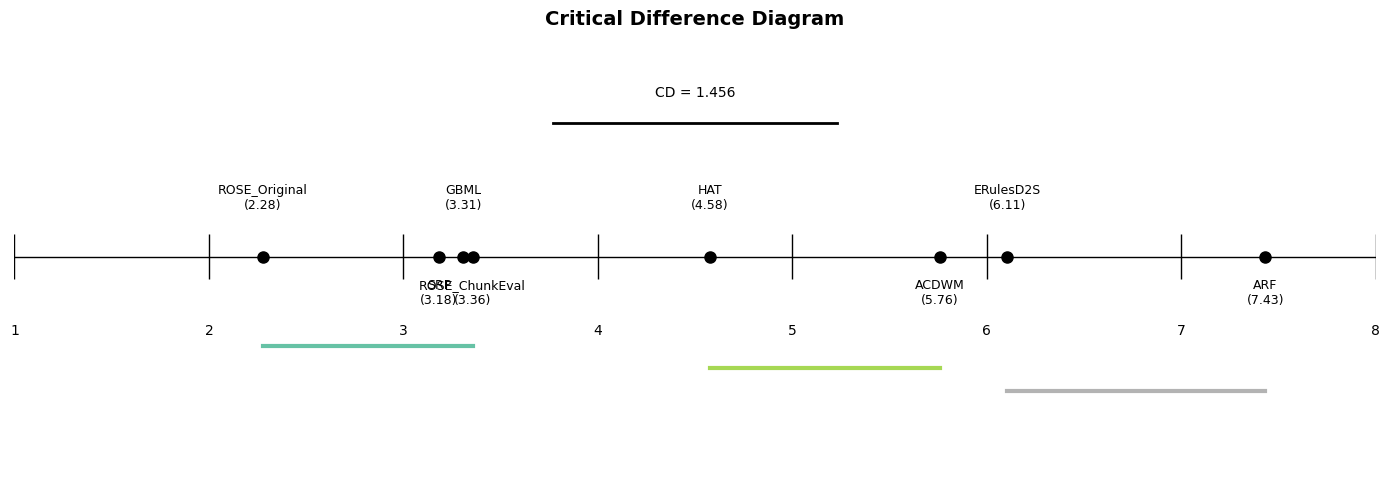


Diagrama salvo em: critical_difference_diagram.png


In [ ]:
# CELULA 5.6: Critical Difference Diagram

import matplotlib.pyplot as plt
import numpy as np

def critical_difference_diagram(mean_ranks_input, cd, ax=None, textspace=1.5):
    """
    Desenha o diagrama de Critical Difference.

    Args:
        mean_ranks_input: Series com ranking medio por modelo (ja ordenado)
        cd: Critical Difference value
        ax: Matplotlib axis
        textspace: Espaco para labels
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    n_models = len(mean_ranks_input)
    models = list(mean_ranks_input.index)
    ranks = mean_ranks_input.values

    # Limites do eixo
    lowv = min(1, min(ranks) - 0.5)
    highv = max(n_models, max(ranks) + 0.5)

    ax.set_xlim(lowv, highv)
    ax.set_ylim(0, 1)

    # Linha horizontal
    ax.hlines(0.5, lowv, highv, color='black', linewidth=1)

    # Ticks
    for i in range(1, n_models + 1):
        ax.vlines(i, 0.45, 0.55, color='black', linewidth=1)
        ax.text(i, 0.35, str(i), ha='center', va='top', fontsize=10)

    # Desenhar Critical Difference
    cd_x = (lowv + highv) / 2 - cd / 2
    ax.plot([cd_x, cd_x + cd], [0.8, 0.8], 'k-', linewidth=2)
    ax.text(cd_x + cd / 2, 0.85, f'CD = {cd:.3f}', ha='center', va='bottom', fontsize=10)

    # Posicionar modelos
    height = 0.6
    for i, (model, rank) in enumerate(zip(models, ranks)):
        y_offset = 0.1 if i % 2 == 0 else -0.05
        ax.plot(rank, 0.5, 'ko', markersize=8)
        ax.text(rank, 0.5 + y_offset, f'{model}\n({rank:.2f})',
                ha='center', va='bottom' if y_offset > 0 else 'top', fontsize=9)

    # Conectar modelos que nao diferem significativamente
    sorted_idx = np.argsort(ranks)
    sorted_models = [models[i] for i in sorted_idx]
    sorted_ranks = ranks[sorted_idx]

    # Identificar grupos
    groups = []
    current_group = [0]

    for i in range(1, len(sorted_ranks)):
        if sorted_ranks[i] - sorted_ranks[current_group[0]] <= cd:
            current_group.append(i)
        else:
            if len(current_group) > 1:
                groups.append(current_group)
            current_group = [i]

    if len(current_group) > 1:
        groups.append(current_group)

    # Desenhar barras para grupos
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(groups), 1)))
    for gi, group in enumerate(groups):
        y = 0.3 - gi * 0.05
        x_start = sorted_ranks[group[0]]
        x_end = sorted_ranks[group[-1]]
        ax.plot([x_start, x_end], [y, y], '-', linewidth=3, color=colors[gi])

    ax.axis('off')
    ax.set_title('Critical Difference Diagram', fontsize=14, fontweight='bold')

    return ax


# Recalcular mean_ranks caso nao esteja definido (seguranca)
if 'mean_ranks' not in dir() or not isinstance(mean_ranks, pd.Series):
    print("Recalculando mean_ranks...")
    rankings = pivot_gmean.rank(axis=1, ascending=False)
    mean_ranks = rankings.mean().sort_values()

# Calcular Critical Difference
n_datasets = len(pivot_gmean)
n_models = len(pivot_gmean.columns)

# Valores criticos de Nemenyi q_alpha para diferentes k (numero de modelos)
# Fonte: Tabelas estatisticas para teste de Nemenyi
# Para alpha=0.05:
nemenyi_q_values = {
    2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728,
    6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164
}
q_alpha = nemenyi_q_values.get(n_models, 2.850)  # Default para 6 modelos

# Formula do CD de Nemenyi
cd = q_alpha * np.sqrt(n_models * (n_models + 1) / (6 * n_datasets))

print("="*80)
print("CRITICAL DIFFERENCE DIAGRAM")
print("="*80)
print(f"N datasets: {n_datasets}")
print(f"N modelos: {n_models}")
print(f"q_alpha (Nemenyi, alpha=0.05, k={n_models}): {q_alpha}")
print(f"Critical Difference (CD): {cd:.4f}")
print()
print("Modelos conectados por uma barra NAO diferem significativamente.")
print()

# Verificar mean_ranks
print(f"Mean ranks (tipo: {type(mean_ranks).__name__}):")
for model, rank in mean_ranks.items():
    print(f"  {model}: {rank:.3f}")
print()

# Desenhar diagrama
fig, ax = plt.subplots(figsize=(14, 5))
critical_difference_diagram(mean_ranks, cd, ax)

plt.tight_layout()
plt.savefig('critical_difference_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDiagrama salvo em: critical_difference_diagram.png")

---
## PARTE 6: RELATORIO FINAL
---

In [ ]:
# CELULA 6.1: Gerar Relatorio Final

print("="*80)
print("RELATORIO FINAL - COMPARACAO DE MODELOS")
print("="*80)
print(f"Data: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()

# 1. Resumo dos Dados
print("1. RESUMO DOS DADOS")
print("-" * 40)
print(f"   Total de datasets: {len(pivot_gmean)}")
print(f"   Total de modelos: {len(pivot_gmean.columns)}")
print(f"   Modelos avaliados: {', '.join(pivot_gmean.columns)}")
print()

# 2. Performance Media
print("2. PERFORMANCE MEDIA (G-mean)")
print("-" * 40)
perf_summary = pivot_gmean.mean().sort_values(ascending=False)
for rank, (model, gmean) in enumerate(perf_summary.items(), 1):
    print(f"   {rank}. {model:15s} {gmean:.4f}")
print()

# 3. Ranking
print("3. RANKING MEDIO")
print("-" * 40)
for rank, (model, mean_rank) in enumerate(mean_ranks.items(), 1):
    print(f"   {rank}. {model:15s} {mean_rank:.3f}")
print()

# 4. Testes Estatisticos
print("4. TESTES ESTATISTICOS")
print("-" * 40)
print(f"   Friedman Test:")
print(f"     - Chi-squared: {stat:.4f}")
print(f"     - p-value: {p_value:.2e}")
print(f"     - Significativo: {'SIM' if p_value < 0.05 else 'NAO'}")
print()
print(f"   Critical Difference (Nemenyi):")
print(f"     - CD = {cd:.4f}")
print()

# 5. Conclusao
print("5. CONCLUSAO")
print("-" * 40)
winner_model = mean_ranks.index[0]
winner_rank = mean_ranks.iloc[0]
winner_gmean = perf_summary[winner_model]

print(f"   MODELO VENCEDOR: {winner_model}")
print(f"     - Ranking medio: {winner_rank:.3f}")
print(f"     - G-mean medio: {winner_gmean:.4f}")
print()

# Verificar se vencedor e estatisticamente superior
second_model = mean_ranks.index[1]
second_rank = mean_ranks.iloc[1]

if abs(winner_rank - second_rank) > cd:
    print(f"   {winner_model} e ESTATISTICAMENTE SUPERIOR a {second_model}")
else:
    print(f"   {winner_model} NAO e estatisticamente diferente de {second_model}")
    print(f"   (diferenca de ranking {abs(winner_rank - second_rank):.3f} < CD {cd:.3f})")

print()
print("="*80)
print("FIM DO RELATORIO")
print("="*80)

RELATORIO FINAL - COMPARACAO DE MODELOS
Data: 2025-11-27 00:21

1. RESUMO DOS DADOS
----------------------------------------
   Total de datasets: 52
   Total de modelos: 8
   Modelos avaliados: ACDWM, ARF, ERulesD2S, GBML, HAT, ROSE_ChunkEval, ROSE_Original, SRP

2. PERFORMANCE MEDIA (G-mean)
----------------------------------------
   1. SRP             0.7536
   2. GBML            0.7364
   3. ROSE_Original   0.7286
   4. ROSE_ChunkEval  0.6839
   5. HAT             0.6613
   6. ACDWM           0.5389
   7. ERulesD2S       0.3985
   8. ARF             0.0000

3. RANKING MEDIO
----------------------------------------
   1. ROSE_Original   2.279
   2. SRP             3.183
   3. GBML            3.308
   4. ROSE_ChunkEval  3.356
   5. HAT             4.577
   6. ACDWM           5.760
   7. ERulesD2S       6.106
   8. ARF             7.433

4. TESTES ESTATISTICOS
----------------------------------------
   Friedman Test:
     - Chi-squared: 466.0000
     - p-value: 2.11e-01
     - Signi

In [ ]:
# CELULA 6.2: Tabela Final de Resultados

print("="*80)
print("TABELA COMPLETA DE RESULTADOS (G-mean por Dataset)")
print("="*80)

# Adicionar coluna de ranking
pivot_with_ranks = pivot_gmean.copy()

# Destacar melhor por linha
def highlight_best(row):
    best_idx = row.idxmax()
    return [f'**{v:.4f}**' if idx == best_idx else f'{v:.4f}' for idx, v in row.items()]

# Mostrar tabela
print(pivot_gmean.round(4).to_string())

print("\n" + "-"*60)
print("MEDIAS:")
print(pivot_gmean.mean().round(4).to_string())

TABELA COMPLETA DE RESULTADOS (G-mean por Dataset)
model                                ACDWM  ARF  ERulesD2S    GBML     HAT  ROSE_ChunkEval  ROSE_Original     SRP
dataset                                                                                                          
AGRAWAL_Abrupt_Chain_Long           0.6011  0.0     0.5595  0.6943  0.5996          0.6645         0.7569  0.7953
AGRAWAL_Abrupt_Simple_Mild          0.7747  0.0     0.5458  0.8696  0.5754          0.7643         0.8920  0.8605
AGRAWAL_Abrupt_Simple_Severe        0.6860  0.0     0.5615  0.8614  0.7679          0.8450         0.9507  0.8920
AGRAWAL_Abrupt_Simple_Severe_Noise  0.6882  0.0     0.5433  0.8341  0.7551          0.8192         0.9501  0.8768
AGRAWAL_Stationary                  0.8921  0.0     0.0000  1.0000  0.9587          0.9934         1.0000  0.9959
AssetNegotiation_F2                 0.8783  0.0     0.0000  0.9670  0.9166          0.9724         0.9868  0.9526
AssetNegotiation_F3                 0

In [ ]:
# CELULA 6.3: Salvar Resultados no Drive

# Copiar resultados de volta para o Drive
print("Salvando resultados no Drive...")

# Salvar CSV consolidado
!cp all_models_consolidated_results.csv "{DRIVE_BASE}/"

# Salvar diagrama
!cp critical_difference_diagram.png "{DRIVE_BASE}/"

# Salvar tabela pivot
pivot_gmean.to_csv('pivot_gmean_all_models.csv')
!cp pivot_gmean_all_models.csv "{DRIVE_BASE}/"

print("\nArquivos salvos no Drive:")
print(f"  - {DRIVE_BASE}/all_models_consolidated_results.csv")
print(f"  - {DRIVE_BASE}/critical_difference_diagram.png")
print(f"  - {DRIVE_BASE}/pivot_gmean_all_models.csv")
print("\nCONCLUIDO!")

Salvando resultados no Drive...
cp: 'all_models_consolidated_results.csv' and '/content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/all_models_consolidated_results.csv' are the same file
cp: 'critical_difference_diagram.png' and '/content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/critical_difference_diagram.png' are the same file
cp: 'pivot_gmean_all_models.csv' and '/content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/pivot_gmean_all_models.csv' are the same file

Arquivos salvos no Drive:
  - /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/all_models_consolidated_results.csv
  - /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/critical_difference_diagram.png
  - /content/drive/Othercomputers/Laptop-CIn/Downloads/DSL-AG-hybrid/pivot_gmean_all_models.csv

CONCLUIDO!
